## Load modules

In [1]:
from tqdm import tqdm

import numpy as np

from qgm import function
from qgm import image
from qgm import fitting
from qgm import parameter
from qgm.deconvolution import deconvolution

import matplotlib.pyplot as plt

## Set image settings

In [2]:
img_setting = parameter.system()

img_setting.set_defaults()
img_setting.psf.set_defaults()

### Point Spread Function (PSF)

In [3]:
if True:
    psf_info = {'Model':'psf',
                'Effective NA': 0.6,
                'Offset count': 0,
                'Peak count': 2500,
                'Wavelength (um)': 0.78
            }
else:
    psf_info = {'Model':'psf',
                'Effective NA': 0.65,
                'Offset count': 0,
                'Peak count': 2500,
                'Wavelength (um)': 0.42
            }

In [4]:
img_setting.psf.set_info(**psf_info)
img_setting.psf.recalc_resolution()
img_setting.psf.info

{'Model': 'psf',
 'Effective NA': 0.6,
 'Wavelength (um)': 0.78,
 'Peak count': 2500,
 'HWHM width - iso (um)': 0.3344230402377111,
 'HWHM width - x (um)': 0.3344230402377111,
 'HWHM width - y (um)': 0.3344230402377111,
 'Offset count': 0,
 'R abbe (um)': 0.65,
 'R Rayleigh (um)': 0.7927854293232279}

### Lattice information

In [5]:
if True:
    lattice1_info = {'Constant (px)': 3.77013,
                    'Constant (um)': 3.77013 * 0.18782061063985978,
                    'Angle (degree)': 19.81638,
                    'Angle (radian)': 19.81638 * np.pi / 180,
                    }
    lattice2_info = {'Constant (px)': 3.78842,
                    'Constant (um)': 3.78842 * 0.18782061063985978,
                    'Angle (degree)': 79.61159,
                    'Angle (radian)': 79.61159 * np.pi / 180,
                    }
else:
    lattice1_info = {'Constant (px)': 3.77013 / 2,
                    'Constant (um)': 3.77013 * 0.18782061063985978 / 2,
                    'Angle (degree)': 19.81638,
                    'Angle (radian)': 19.81638 * np.pi / 180,
                    }
    lattice2_info = {'Constant (px)': 3.78842 / 2,
                    'Constant (um)': 3.78842 * 0.18782061063985978 / 2,
                    'Angle (degree)': 79.61159,
                    'Angle (radian)': 79.61159 * np.pi / 180,
                    }

In [6]:
img_setting.lattice['Lattice 1'].set_info(**lattice1_info)
img_setting.lattice['Lattice 2'].set_info(**lattice2_info)

img_setting.lattice['Origins']['X Center (um)'] = np.array([0])
img_setting.lattice['Origins']['Y Center (um)'] = np.array([0])
img_setting.lattice['Origins']['Goodness'] = np.array([1])

### Image center and magnification

In [7]:
img_magnification = 85

img_size = {'x': 25, 'y': 25, 'unit': 'um'}

if img_size['unit'] == 'px':
    size_x = img_size['x']
    size_y = img_size['y']
else:
    size_x = int(img_size['x'] / img_setting.info['Effective Pixel size (um/px)'])
    size_y = int(img_size['y'] / img_setting.info['Effective Pixel size (um/px)'])

In [8]:
system_info = {'Magnification': img_magnification,
               'Cloud center (px)': (size_x/2, size_y/2),
               'Cloud center (um)': (0, 0),
               'EM gain': 300,
               }

In [9]:
img_setting.set_info(**system_info)
img_setting.recalc_effective_pixel_size()

img_setting.info

{'Camera model': 'Andor iXon Ultra DU-897U-CS0-EXF',
 'Camera maker': 'Oxford Instruments',
 'Pixel size (um/px)': 16,
 'Effective Pixel size (um/px)': 0.18823529411764706,
 'Magnification': 85,
 'EM gain': 300,
 'Pre amp.': 3,
 'HS speed (MHz)': 17.0,
 'VS speed (us/px)': 3.3,
 'Temperature': -75,
 'Objective NA': 0.65,
 'Cloud center (px)': (66.0, 66.0),
 'Cloud center (um)': (0, 0)}

## Generate simulated image

In [10]:
cmap = image.generate_cmap(['#330000', 'r', 'w'])

In [11]:
img = image.image()
img.system = img_setting

img.image = np.zeros((size_y, size_x))
img.system.set_info(**system_info)
xy_mesh = img.generate_xymesh()
(xs, ys) = img.generate_lattice_sites(Nsite=201, rxlim=size_x, rylim=size_y, unit='um', limits='square')


x0, x1, y0, y1 = [-img_size['x']/2, img_size['x']/2, -img_size['y']/2, img_size['y']/2]

img.set_ROI(ROI= [x0, x1, y0, y1])
xymesh_ROI = img.xymesh_ROI

conditions = (xs >= np.min(xy_mesh[0])) * (xs <= np.max(xy_mesh[0]))
conditions *= (ys >= np.min(xy_mesh[1])) * (ys <= np.max(xy_mesh[1]))

xs = xs[conditions]
ys = ys[conditions]

In [12]:
np.random.seed(0)

threshold = 0.9
pos_bool = np.random.rand(len(xs)) > threshold

xs_ex = xs[pos_bool]
ys_ex = ys[pos_bool]
Nex = len(xs_ex)

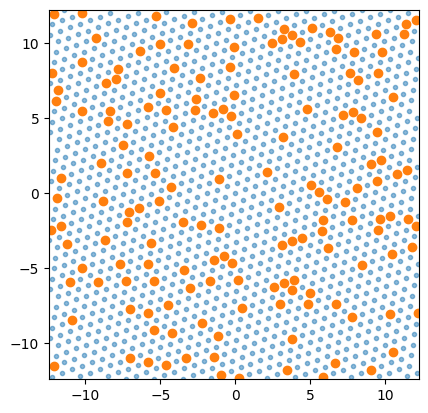

In [13]:
plt.figure(dpi=100)

plt.plot(xs, ys, '.', alpha=0.5)
plt.plot(xs_ex, ys_ex, 'o')
plt.gca().set_aspect('equal')

plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

plt.show()

In [14]:
photon = 200
photon_noise = 10
print('S/N = %.2f' % (photon/photon_noise))

Nphs = np.random.poisson(photon, Nex)

xmax = np.max(xs) * 1.25
ymax = np.max(ys) * 1.25

Nsample = 10000
spx_eff = img_setting.info['Effective Pixel size (um/px)']

alpha_psf = 2 * np.pi * img_setting.psf.info['Effective NA'] / img_setting.psf.info['Wavelength (um)']
show_progress = True

S/N = 20.00


In [24]:
img.image *= 0

if show_progress:
    for i in tqdm(range(Nex)):
        N = 0
        p_psf = np.array([1, xs_ex[i], ys_ex[i], alpha_psf, 0])

        xs_rnd = np.array([])
        ys_rnd = np.array([])

        while N < Nphs[i]:
            x_rnd = 2 * xmax * (np.random.rand(Nsample) - 0.5)
            y_rnd = 2 * ymax * (np.random.rand(Nsample) - 0.5)
            z_rnd = np.random.rand(Nsample)
            s = function.psf_2d((x_rnd, y_rnd), *p_psf)
            
            xs_rnd = np.append(xs_rnd, x_rnd[s > z_rnd])
            ys_rnd = np.append(ys_rnd, y_rnd[s > z_rnd])
            
            N = xs_rnd.size

        if N > Nphs[i]:
            xs_rnd = xs_rnd[0:Nphs[i]]
            ys_rnd = ys_rnd[0:Nphs[i]]

            N = xs_rnd.size
        
        for j in range(len(xs_rnd)):
            x_tmp1 = xy_mesh[0] >= xs_rnd[j] - spx_eff
            x_tmp2 = xy_mesh[0] <= xs_rnd[j]
            x_tmp = x_tmp1 * x_tmp2
            y_tmp1 = xy_mesh[1] >= ys_rnd[j] - spx_eff
            y_tmp2 = xy_mesh[1] <= ys_rnd[j] 
            y_tmp = y_tmp1 * y_tmp2

            img.image += x_tmp * y_tmp

Nbgs = np.random.poisson(photon_noise, img.image.shape)
img.image += Nbgs

100%|██████████| 160/160 [00:09<00:00, 17.28it/s]


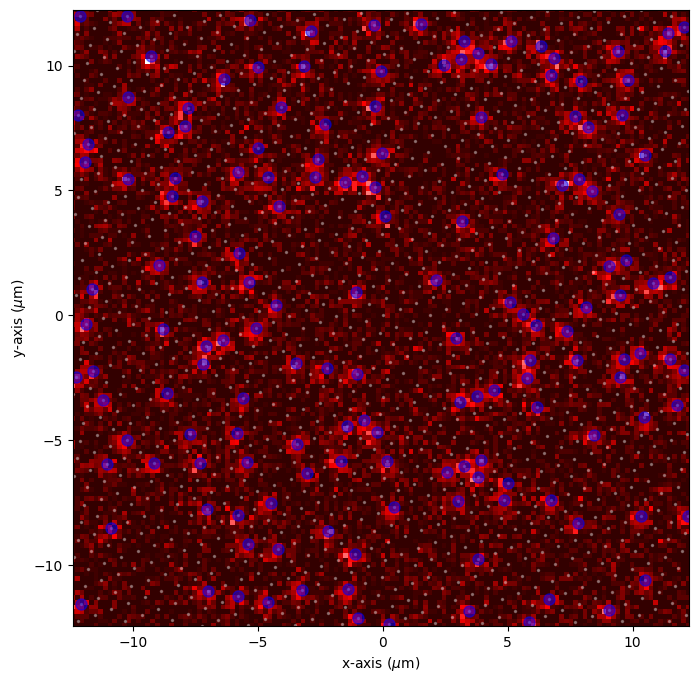

In [25]:
plt.figure(figsize=(8,8), dpi=100)

plt.pcolormesh(xy_mesh[0], xy_mesh[1], img.image, cmap=cmap, vmin=photon_noise)
plt.plot(xs, ys, 'w.', ms=3, alpha=0.3)
plt.plot(xs_ex, ys_ex, 'bo', ms=8, alpha=0.5)
plt.gca().set_aspect('equal')

plt.xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
plt.ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))

plt.xlabel('x-axis ($\mu$m)')
plt.ylabel('y-axis ($\mu$m)')

plt.show()

### Deconvolution

In [26]:
(xs1_test, ys1_test) = img.generate_lattice_sites(Nsite=401, rxlim=np.max([x0, x1])+1, rylim=np.max([y0, y1])+1, unit='um', limits='square', origin='average')

xs1_test = img.system.lattice['Lattice sites']['X Center']
ys1_test = img.system.lattice['Lattice sites']['Y Center']

In [27]:
# img.generate_psfm(psf_model='gaussian')
img.generate_psfm()
img_test_dec, factor_evol1 = deconvolution(img, Niter=10)

xs_est = img.system.lattice['Lattice sites']['X Center']
ys_est = img.system.lattice['Lattice sites']['Y Center']
amp_est = img.system.lattice['Lattice sites']['Amplitude']

In [45]:
img.system.lattice['Lattice sites'] = img.system.lattice['Lattice sites'][conditions]

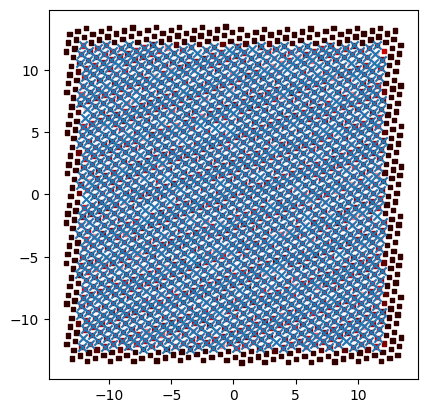

In [46]:
conditions = (xs_est >= np.min(xymesh_ROI[0])) * (xs_est <= np.max(xymesh_ROI[0]))
conditions *= (ys_est >= np.min(xymesh_ROI[1])) * (ys_est <= np.max(xymesh_ROI[1]))

plt.scatter(xs1_test, ys1_test, marker='s', s=10, c=np.array(factor_evol1[:,10])[:,0], vmin=0, cmap=cmap)
plt.scatter(xs1_test[conditions], ys1_test[conditions], marker='x')

plt.gca().set_aspect(1)

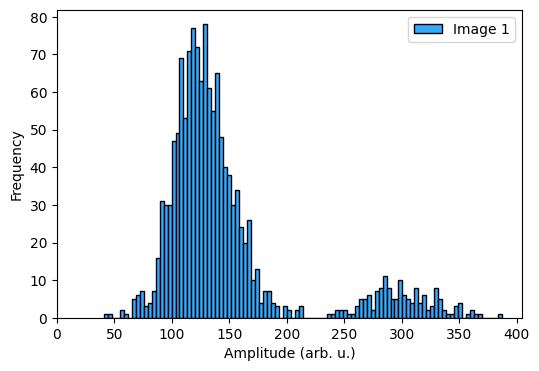

In [51]:
fig, axs = plt.subplots(1, 1, sharex=True, dpi=100, figsize=(6 ,4))

# Remove horizontal space between axes
fig.subplots_adjust(hspace=0.2)

for ax, A, legend_label in zip([axs],
                                 [img.system.lattice['Lattice sites']['Amplitude']],
                                 ['Image 1']):
    # ax.hist(A, bins=100, ec='k', fc='#33aaff', label=legend_label)
    ax.hist(A[conditions], bins=100, ec='k', fc='#33aaff', label=legend_label)
    ax.set_xlim(0,)
    # ax.set_ylim(0, 200)

    # ax.vlines(20000, ymin=0, ymax=10000, color='gray', ls='--')
    
    ax.legend()
    ax.set_ylabel('Frequency')

plt.xlabel('Amplitude (arb. u.)')

plt.show()

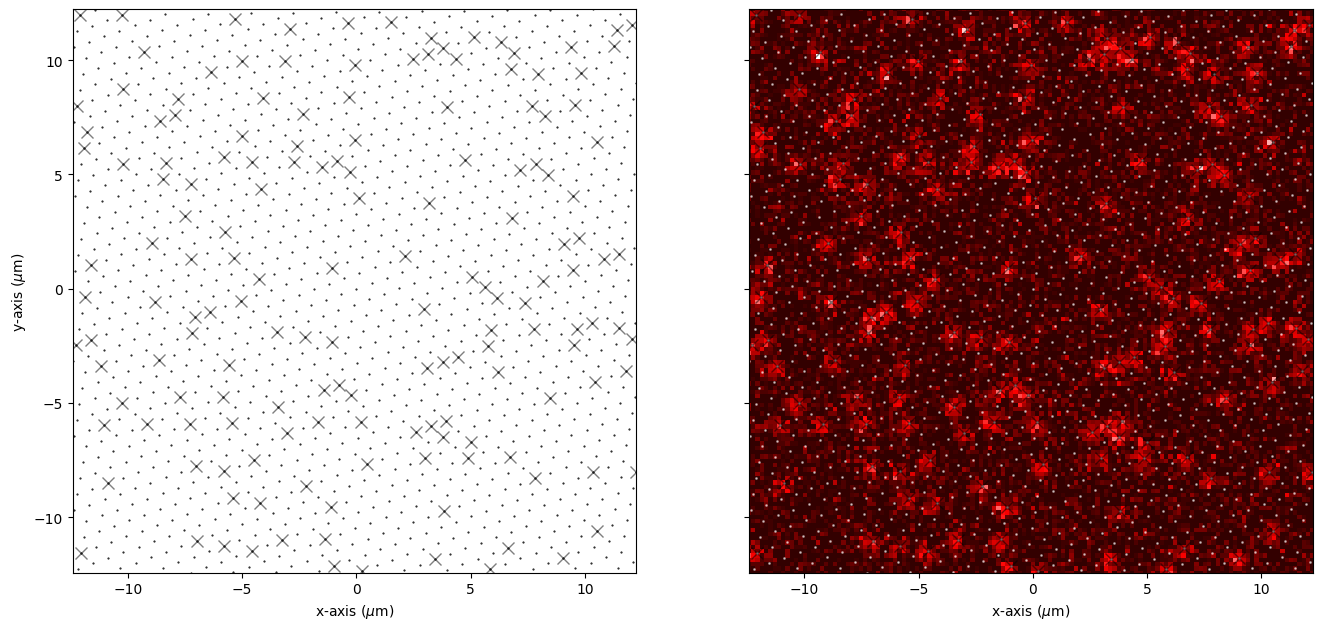

In [30]:
deconv_threshold = 400

fig, axs = plt.subplots(1, 2, figsize=(16,8), dpi=100, sharex=True, sharey=True)

axs[1].pcolormesh(xy_mesh[0], xy_mesh[1], img.image, cmap=cmap, vmin=photon_noise)
axs[0].plot(xs, ys, 'k.', ms=1)
axs[1].plot(xs, ys, 'w.', ms=2, alpha=0.5)

for ax in axs:
    ax.plot(xs_ex, ys_ex, 'kx', ms=8, alpha=0.5)
    ax.plot(xs_est[amp_est > deconv_threshold], ys_est[amp_est > deconv_threshold], 'bo', ms=10, alpha=0.4)
    
    ax.set_aspect('equal')
    ax.set_xlabel('x-axis ($\mu$m)')

axs[0].set_xlim(np.min(xy_mesh[0]), np.max(xy_mesh[0]))
axs[0].set_ylim(np.min(xy_mesh[1]), np.max(xy_mesh[1]))


axs[0].set_ylabel('y-axis ($\mu$m)')

plt.show()